# Block F analysis — the Block E analyses reproduced for the reweighted loss

This notebook **loads** the tables and figures that `run_e3_for_block_f.py` wrote by running
Block E's E3 scripts against the Block F networks; it computes nothing. Every number comes from
`results/*.csv` and every figure from `figures/*.png`.

The error is the **radial** distance at the first SciFi plane, z1 = 7,826 mm, between the
network's endpoint and the RK6 endpoint of the same track: r = sqrt(dx^2 + dy^2), on the
1,452 test tracks.

Block F has three runs (N = 64 q = 2, N = 128 q = 8, N = 256 q = 16); a run appears here once it
has finished. Two caveats: the over-training check and the case study's loss-against-momentum
panel evaluate **Block E's** loss on the network, which is not the loss Block F was trained on
(its chain-error ratios are what to read); and the case study's 'best network' is chosen on
validation among the finished Block F runs.


In [1]:
import pandas as pd, os
from IPython.display import Image, display
pd.set_option("display.width", 200, "display.max_columns", 50)
R = lambda n: pd.read_csv(os.path.join("results", n))
F = lambda n: display(Image(os.path.join("figures", n)))

## 1. error(q, dz) for the chains, and for a single step

,N,q,dz_mm,med_um,p95_um,p99_um,exact_med_um,block_d_med_um,us_per_track,val_rounds_mean_um,val_rounds_std_um
0,64,2,80.90,88.826127,1399.098289,4033.400635,0.146544,2304.339087,657.2,88.081151,6.039419
1,128,8,40.45,104.624698,1611.382226,4135.492733,0.011480,3212.304211,1321.5,104.076205,7.335105
2,256,16,20.23,92.158804,1229.545184,3404.299111,0.001050,NaN,3654.8,88.387823,9.410372


,what,med_um,p95_um,p99_um,mean_um,max_um,frac_above_1mm,worst5pct_share,n
0,straight line,450541.744575,1.252354e+06,1.448745e+06,532052.830255,1.832614e+06,1.000000,0.130619,1452
1,material floor (real SciFi state vs the RK6 tr...,1896.348151,1.343206e+04,3.018207e+04,3930.303541,1.176342e+05,0.665978,0.322064,1452


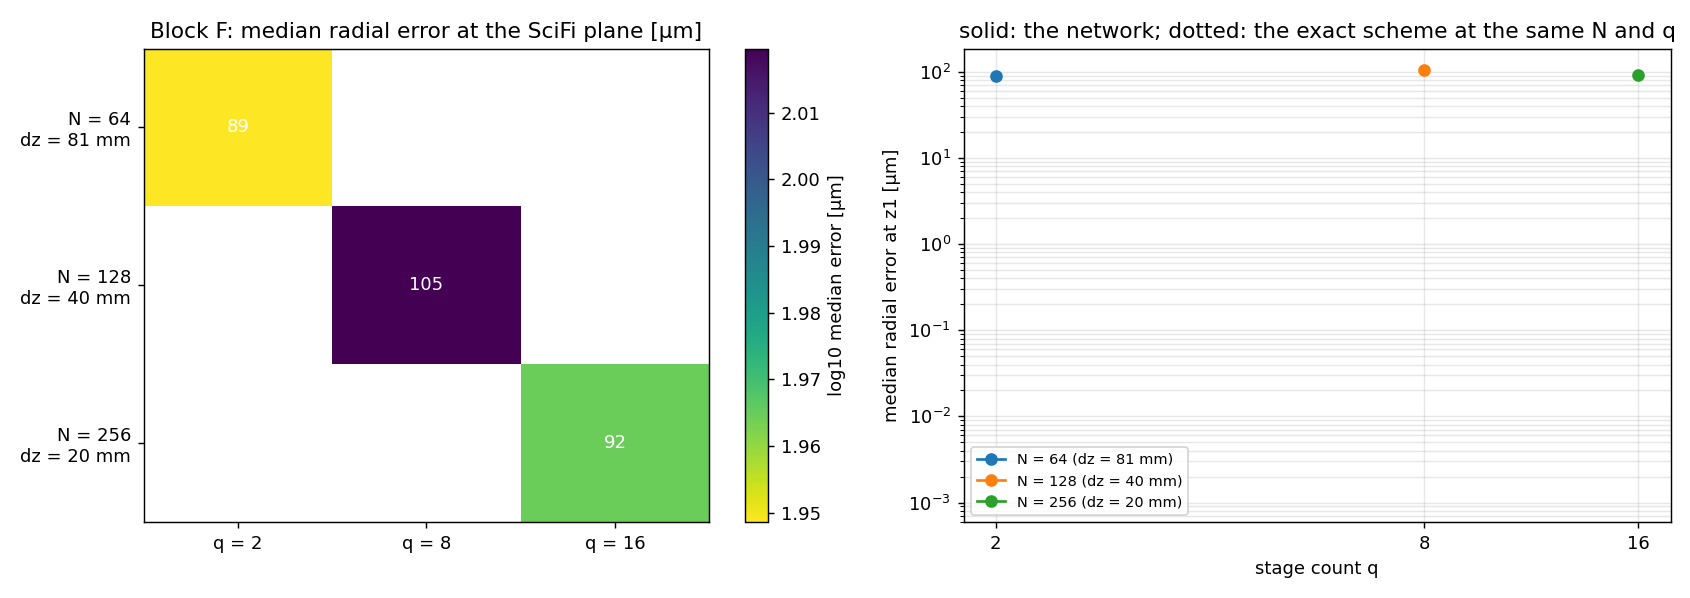

In [2]:
chain = R("error_qdz_chain.csv")
display(chain[["N","q","dz_mm","med_um","p95_um","p99_um","exact_med_um","block_d_med_um","us_per_track",
               "val_rounds_mean_um","val_rounds_std_um"]].sort_values(["N","q"]))
display(R("comparators.csv"))
F("error_qdz.png")

,N,q,dz_mm,step_med_um,step_p95_um,straight_line_step_med_um,step_over_straight,chain_med_um
0,64,2,80.90,0.433415,4.915799,95.221188,0.004552,80.608050
1,128,8,40.45,0.220914,2.316088,23.817459,0.009275,95.543629
2,256,16,20.23,0.058080,0.787122,5.955220,0.009753,84.353029


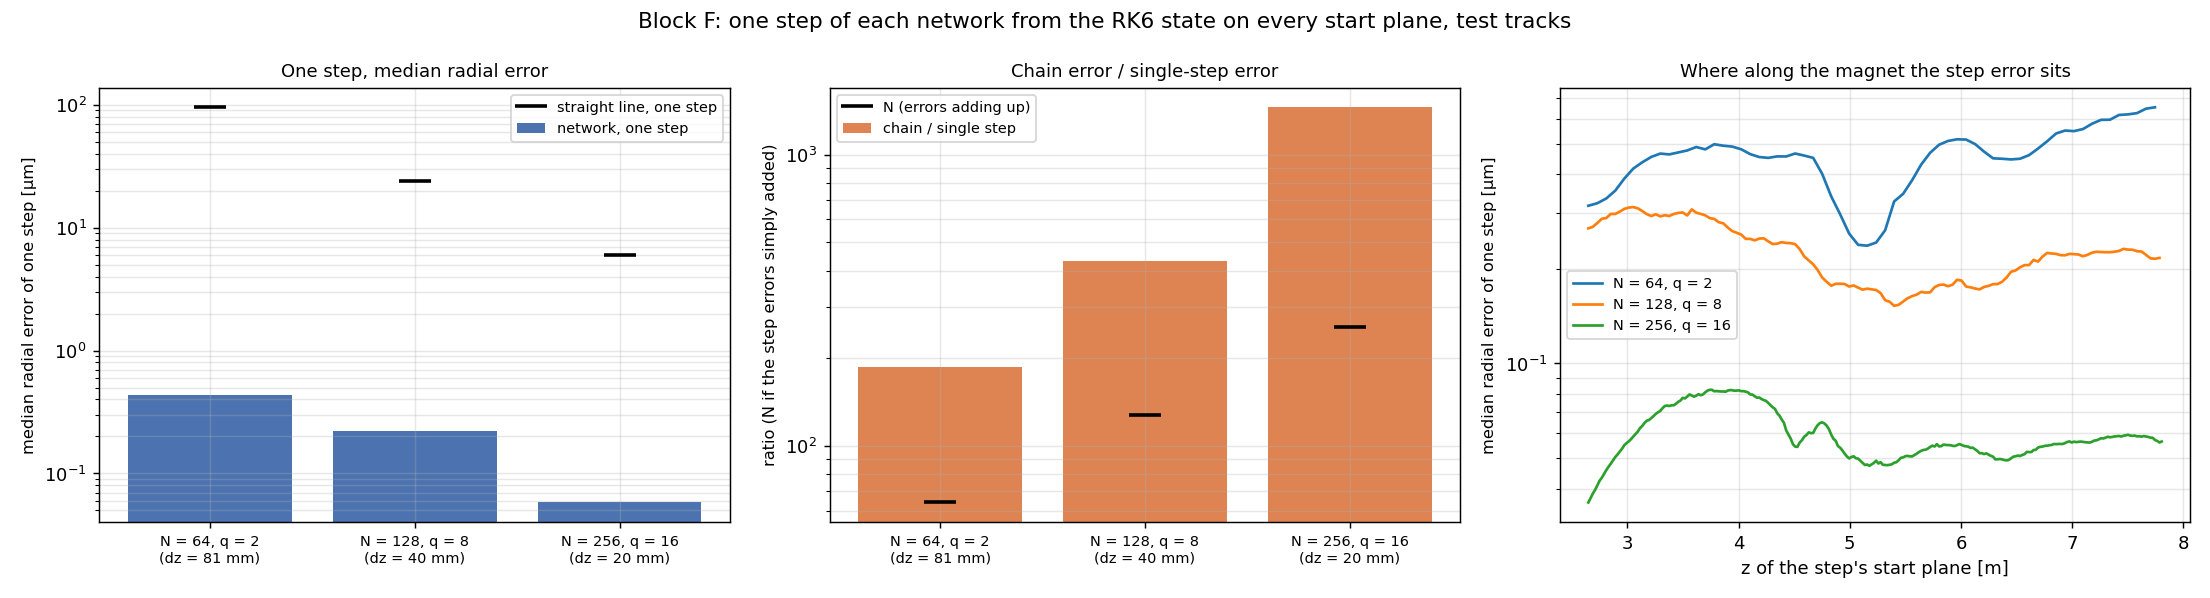

In [3]:
step = R("error_qdz_single_step.csv")
display(step[["N","q","dz_mm","step_med_um","step_p95_um","straight_line_step_med_um",
              "step_over_straight","chain_med_um"]].sort_values(["N","q"]))
F("single_step.png")

## 2. Where the error is built up, and the tails

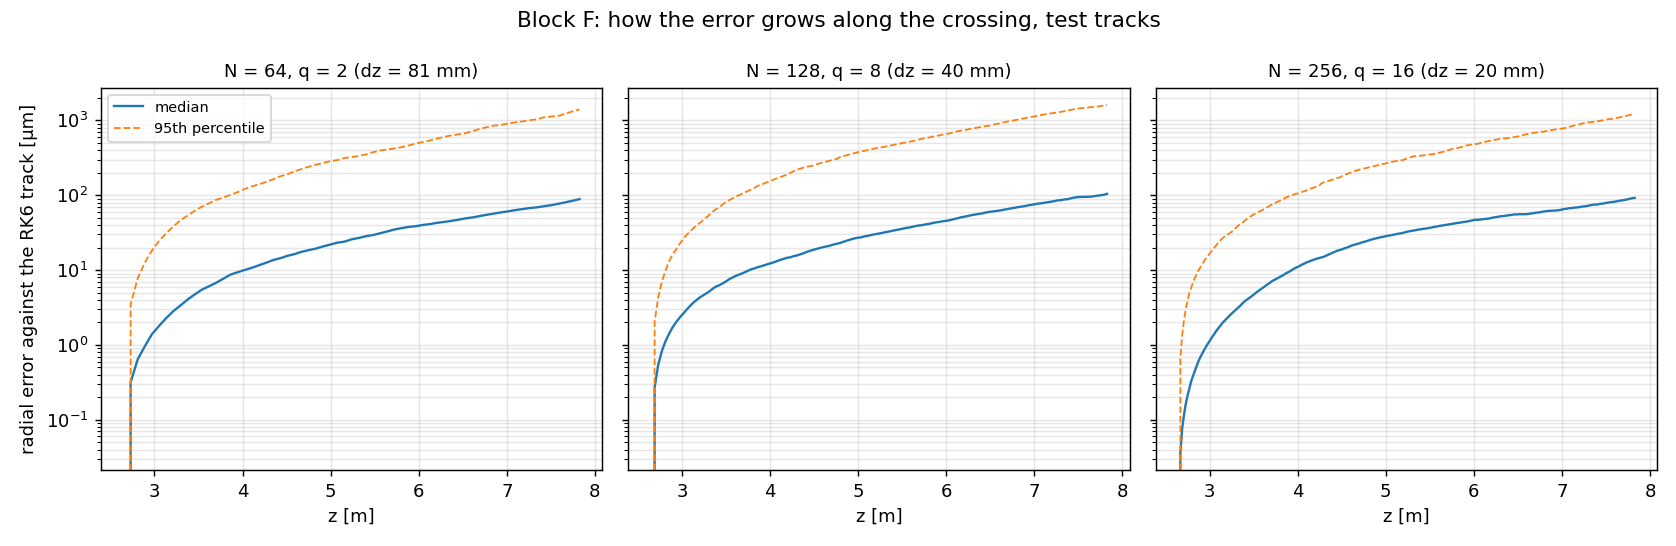

,N,q,med_um,p95_um,p99_um,max_um,frac_above_1mm,worst5pct_share
0,64,2,88.826127,1399.098289,4033.400635,8532.751202,0.071625,0.459213
2,256,16,92.158804,1229.545184,3404.299111,10000.034825,0.065427,0.443721
1,128,8,104.624698,1611.382226,4135.492733,11799.861149,0.095730,0.430467


,N,q,us_per_track,med_um,n_parameters
0,64,2,657.2,88.826127,18956
2,256,16,3654.8,92.158804,26180
1,128,8,1321.5,104.624698,22052


In [4]:
F("error_vs_z.png"); display(R("tails.csv").sort_values("med_um")); display(R("cost_accuracy.csv").sort_values("med_um"))

## 3. Every model: each component of the state against momentum

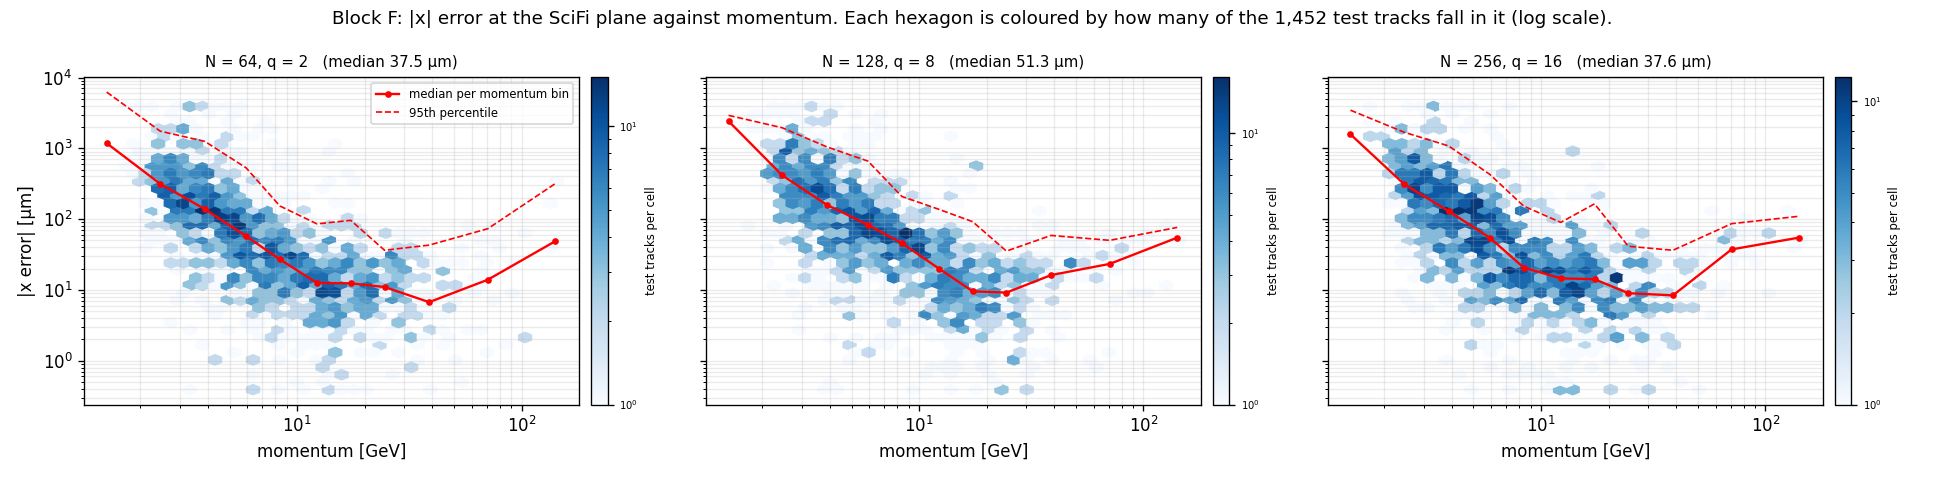

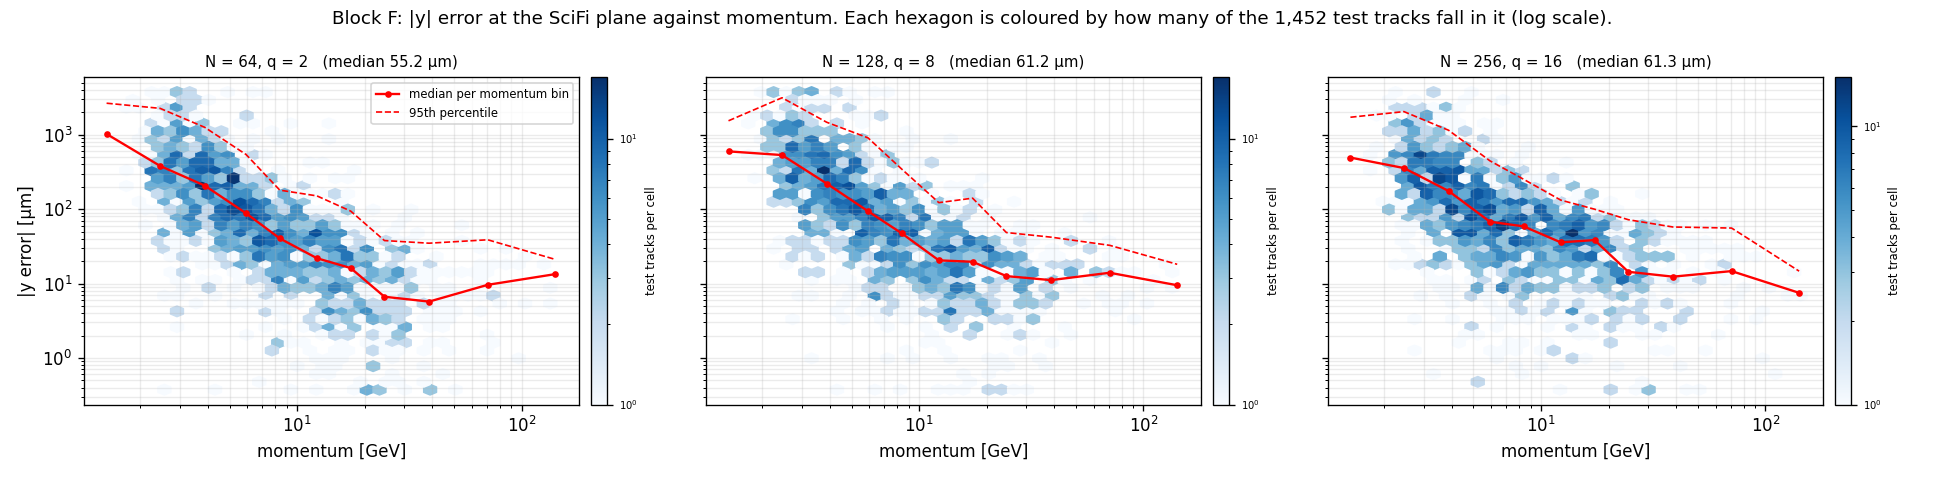

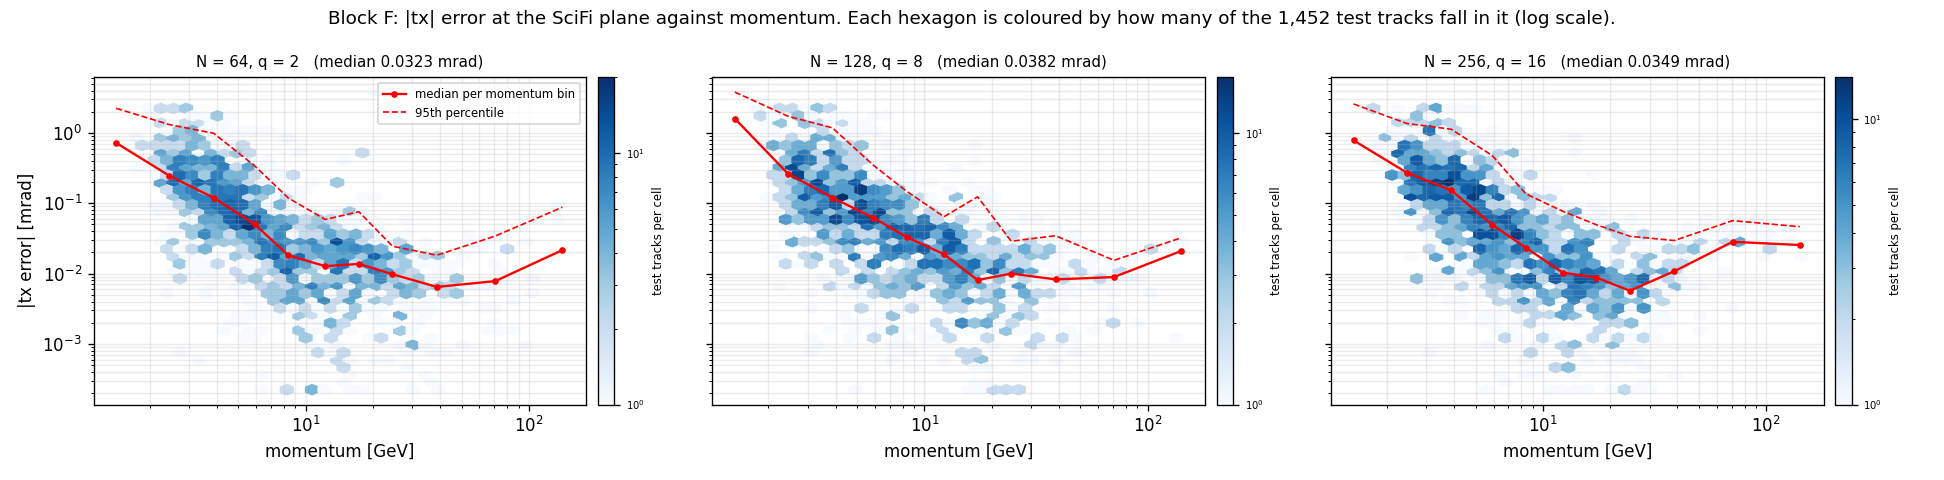

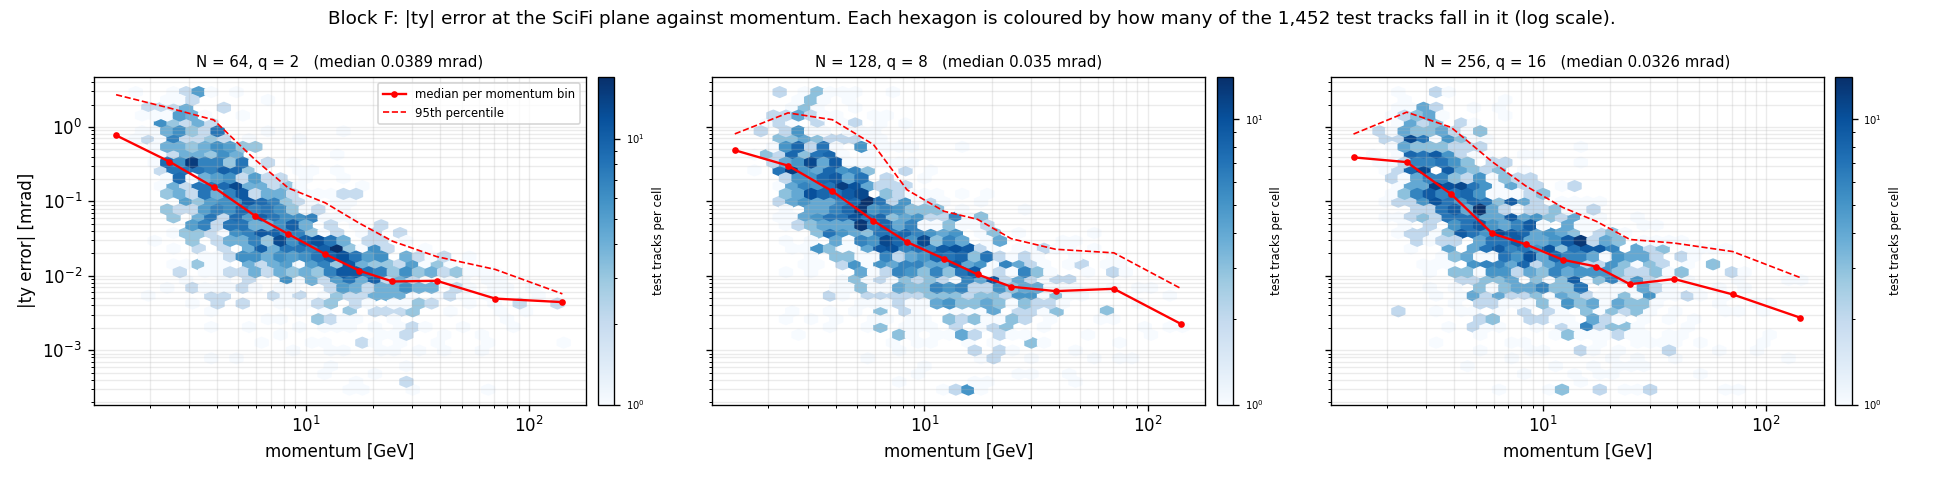

,N,q,component,unit,p_lo,p_hi,n,med,p95,signed_mean
0,64,2,x,µm,1.0,2.0,5,1181.025695,6229.159231,493.837553
1,64,2,x,µm,2.0,3.0,159,314.843256,1747.477212,82.975389
2,64,2,x,µm,3.0,5.0,341,138.439685,1252.849343,-90.012480
3,64,2,x,µm,5.0,7.0,233,57.389298,529.835552,-1.496395
4,64,2,x,µm,7.0,10.0,197,26.969949,153.243132,30.565421


In [5]:
for c in ("x","y","tx","ty"): F("error_vs_p_%s.png" % c)
R("error_vs_p.csv").head()

## 4. Convergence: the training loss and the error it buys


,N,q,restarts,rounds,loss_first,loss_final,loss_end_first,loss_end_last,loss_end_last8_ratio,val_first,val_final,val_last8_mean,val_last8_std,val_best,val_best_round,test_final
0,64,2,1000,40,5.411380e-09,2.064749e-11,1.461975e-10,2.064749e-11,0.976607,353.729267,85.098774,88.081151,6.039419,74.585810,39,80.608050
1,128,8,1000,40,1.174356e-09,4.424376e-12,3.246597e-11,4.424376e-12,1.047539,379.865034,101.906158,104.076205,7.335105,91.157983,19,95.543629
2,256,16,1807,74,3.120693e-10,8.945093e-13,7.575017e-12,8.945093e-13,1.054980,353.918685,87.550767,88.387823,9.410372,73.126020,67,84.353029


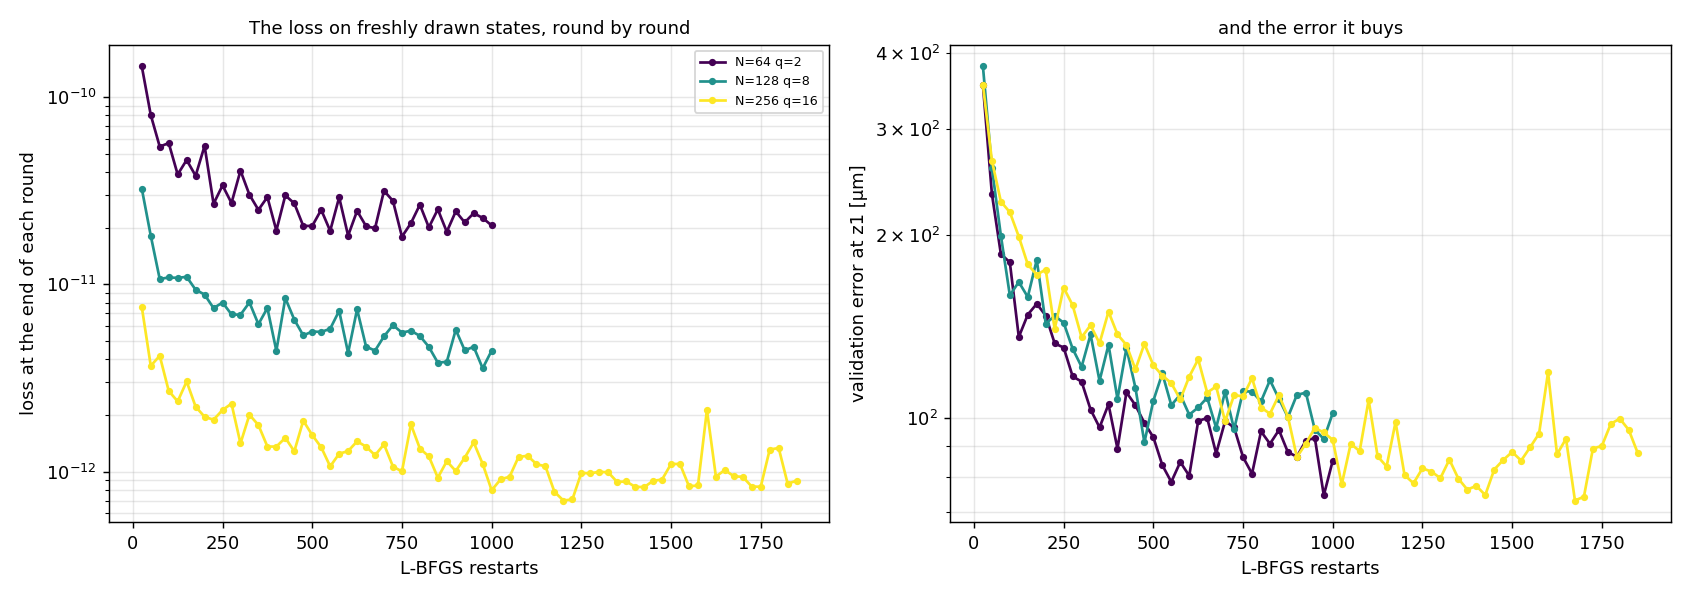

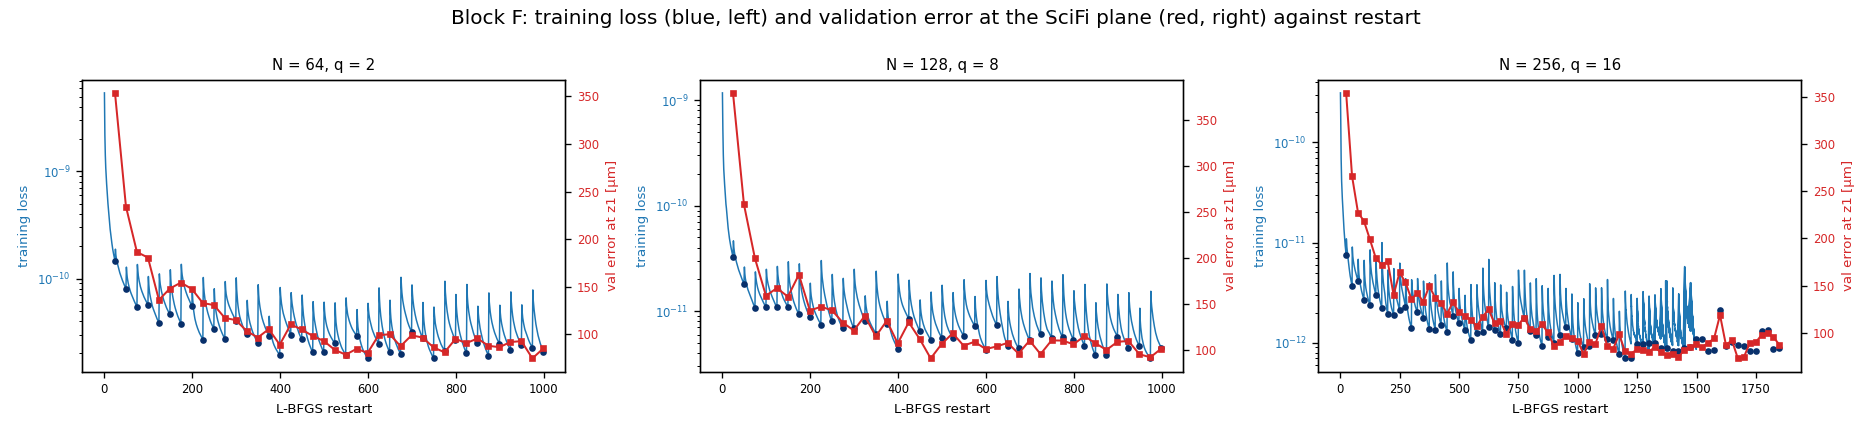

In [6]:
display(R("convergence.csv")); F("convergence_summary.png"); F("convergence_grid.png")

## 5. Over-training check (all three splits) — chain error only; the loss column is Block E's loss, not the trained one


In [7]:
display(R("overtraining.csv")); R("split_comparison.csv").head(9)

,N,q,converged,confirmed,restarts,train_pos_med_um,val_pos_med_um,test_pos_med_um,test_over_train_pos,val_over_train_pos,train_loss,test_loss,test_over_train_loss
0,64,2,False,NaN,1000,83.218530,85.098774,80.608050,0.968631,1.022594,1.989866e-08,1.693463e-08,0.851044
1,128,8,False,NaN,1000,97.493505,101.906158,95.543629,0.980000,1.045261,6.155685e-09,3.411003e-09,0.554122
2,256,16,False,NaN,1807,83.984536,87.550767,84.353029,1.004388,1.042463,1.245017e-09,6.438479e-10,0.517140


,N,q,split,n_tracks,pos_med_um,pos_p95_um,x_med_um,y_med_um,tx_med_mrad,ty_med_mrad,loss_on_rk6_states,n_states
0,64,2,train,11567,83.218530,1292.286821,36.569333,58.452619,0.033082,0.044636,1.989866e-08,32000
1,64,2,val,1463,85.098774,1448.256948,39.143993,61.791165,0.033588,0.042966,3.113611e-08,32000
2,64,2,test,1452,80.608050,1245.984838,37.528512,55.204035,0.032320,0.038898,1.693463e-08,32000
3,128,8,train,11567,97.493505,1476.595957,53.481572,65.576044,0.039315,0.035031,6.155685e-09,32000
4,128,8,val,1463,101.906158,1859.826369,54.876754,66.346173,0.038240,0.033650,6.191223e-09,32000
5,128,8,test,1452,95.543629,1479.428343,51.267928,61.198791,0.038165,0.035046,3.411003e-09,32000
6,256,16,train,11567,83.984536,1229.205164,37.036101,62.910603,0.034956,0.033883,1.245017e-09,32000
7,256,16,val,1463,87.550767,1303.064758,39.364005,66.355190,0.035817,0.033265,8.078867e-10,32000
8,256,16,test,1452,84.353029,1115.024915,37.630441,61.265780,0.034883,0.032579,6.438479e-10,32000


## 6. Case study: the best network on its own

Chosen on the validation tracks (mean error over the last eight rounds), so the test
tracks below were not used to pick it.

,what,med_um,p95_um,p99_um,max_um,frac_above_1mm
0,"this network (N = 64, q = 2)",88.826127,1.399098e+03,4.033401e+03,8.532751e+03,0.071625
1,the exact scheme at the same N and q,0.146544,1.168808e+00,1.811280e+01,1.698089e+02,0.000000
2,"Block D: one network per step, same N and q",2304.339087,1.020070e+04,1.724374e+04,6.463810e+04,0.786501
3,the straight line,450541.744575,1.252354e+06,1.448745e+06,1.832614e+06,1.000000
4,the material floor (real SciFi state vs the RK...,1896.348151,1.343206e+04,3.018207e+04,1.176342e+05,0.665978


,component,unit,p_lo,p_hi,n,med,p95,signed_mean,signed_median
0,x,µm,1.0,2.0,5,1181.025695,6229.159231,493.837553,-421.351208
1,x,µm,2.0,3.0,159,314.843256,1747.477212,82.975389,141.078938
2,x,µm,3.0,5.0,341,138.439685,1252.849343,-90.012480,2.526217
3,x,µm,5.0,7.0,233,57.389298,529.835552,-1.496395,-15.166739
4,x,µm,7.0,10.0,197,26.969949,153.243132,30.565421,16.774358
5,x,µm,10.0,15.0,208,12.526035,85.586162,-9.857565,-2.224243
6,x,µm,15.0,20.0,109,12.380451,95.999345,4.527789,-8.373708
7,x,µm,20.0,30.0,115,10.982510,36.322411,-10.010714,-8.952991
8,x,µm,30.0,50.0,55,6.712585,42.909188,-6.423534,-2.110549
9,x,µm,50.0,100.0,24,13.920430,73.165447,-20.438319,-13.274826


,group,n,med_r_um,med_p_GeV,med_eta,frac_below_5GeV,frac_above_25GeV
0,worst 5 percent,73,2296.265762,3.048295,2.279807,0.821918,0.000000
1,the rest,1379,79.230031,7.224016,3.598311,0.322698,0.097172
2,eta 2.0-2.5,158,884.922677,3.714976,2.302208,0.702532,0.000000
3,eta 2.5-3.0,255,286.485693,4.731944,2.784341,0.560784,0.003922
4,eta 3.0-3.5,292,133.411632,5.414636,3.253186,0.428082,0.030822
5,eta 3.5-4.0,302,51.196131,7.842330,3.760231,0.268212,0.086093
6,eta 4.0-4.5,249,28.388965,12.230441,4.251285,0.128514,0.180723
7,eta 4.5-5.0,196,16.479535,15.448697,4.709067,0.066327,0.270408
8,charge positive,739,84.003729,6.719738,3.539638,0.355886,0.086604
9,charge negative,713,91.631908,6.994097,3.515844,0.339411,0.098177


,p_lo,p_hi,n,loss_med,loss_share,step_med_um,chain_med_um
0,1.0,2.0,5,4.522872e-08,0.019671,3.904010,2509.611803
1,2.0,3.0,159,1.606919e-08,0.341256,2.938860,603.314406
2,3.0,5.0,341,2.018797e-09,0.592547,1.344292,278.670402
3,5.0,7.0,233,2.512605e-10,0.039485,0.625259,121.322086
4,7.0,10.0,197,7.627282e-11,0.004767,0.332592,51.514708
5,10.0,15.0,208,2.075237e-11,0.001747,0.176596,30.365973
6,15.0,20.0,109,8.579093e-12,0.000462,0.141913,25.944387
7,20.0,30.0,115,4.518258e-12,0.000047,0.127273,16.142222
8,30.0,50.0,55,3.997079e-12,0.000011,0.126071,16.160671
9,50.0,100.0,24,2.705509e-12,0.000004,0.142909,19.754186


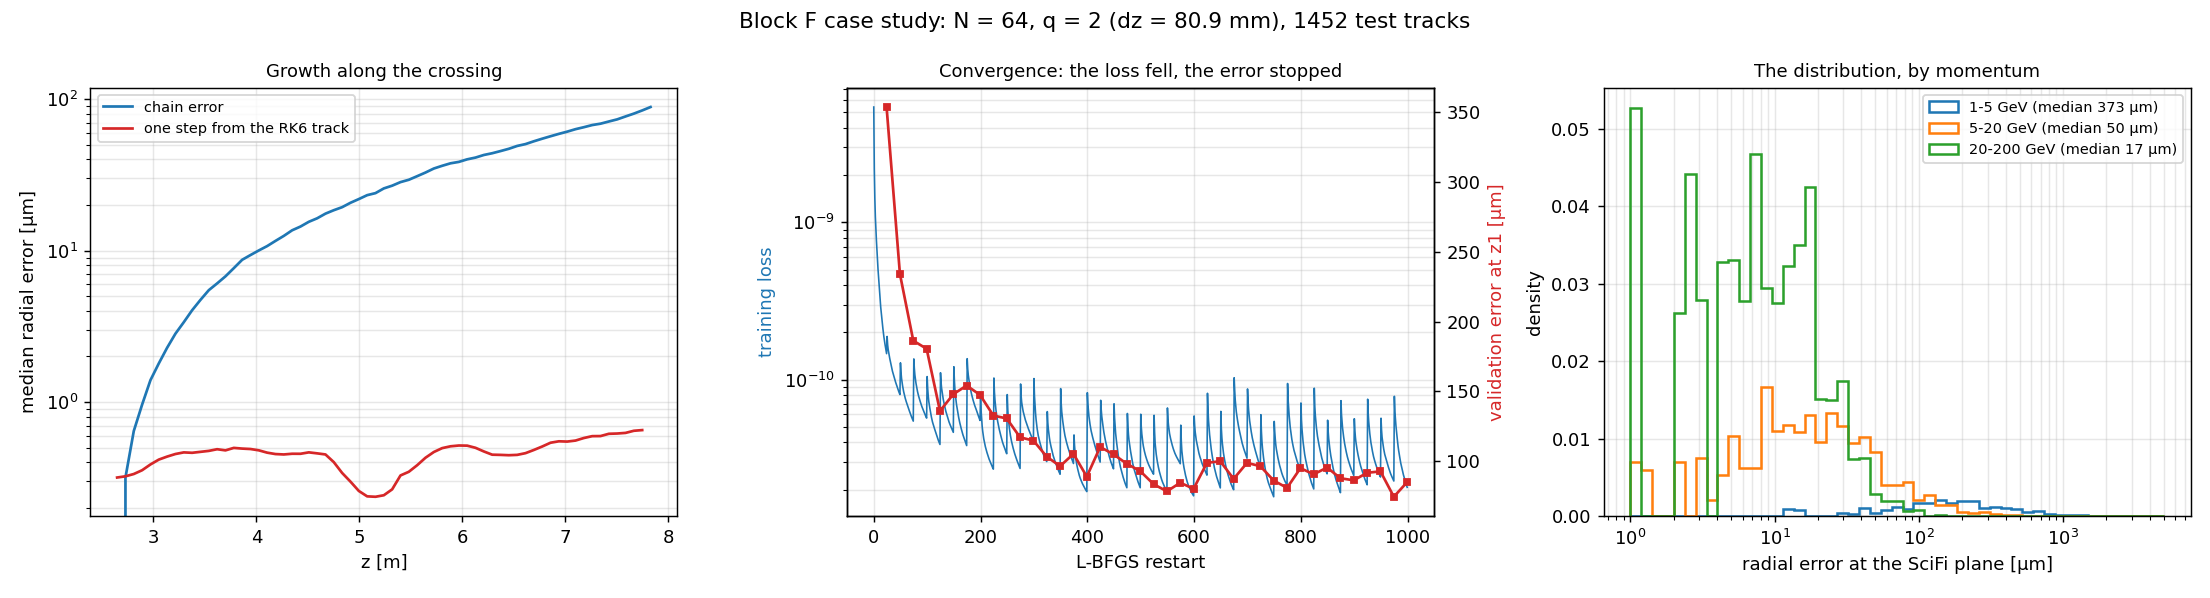

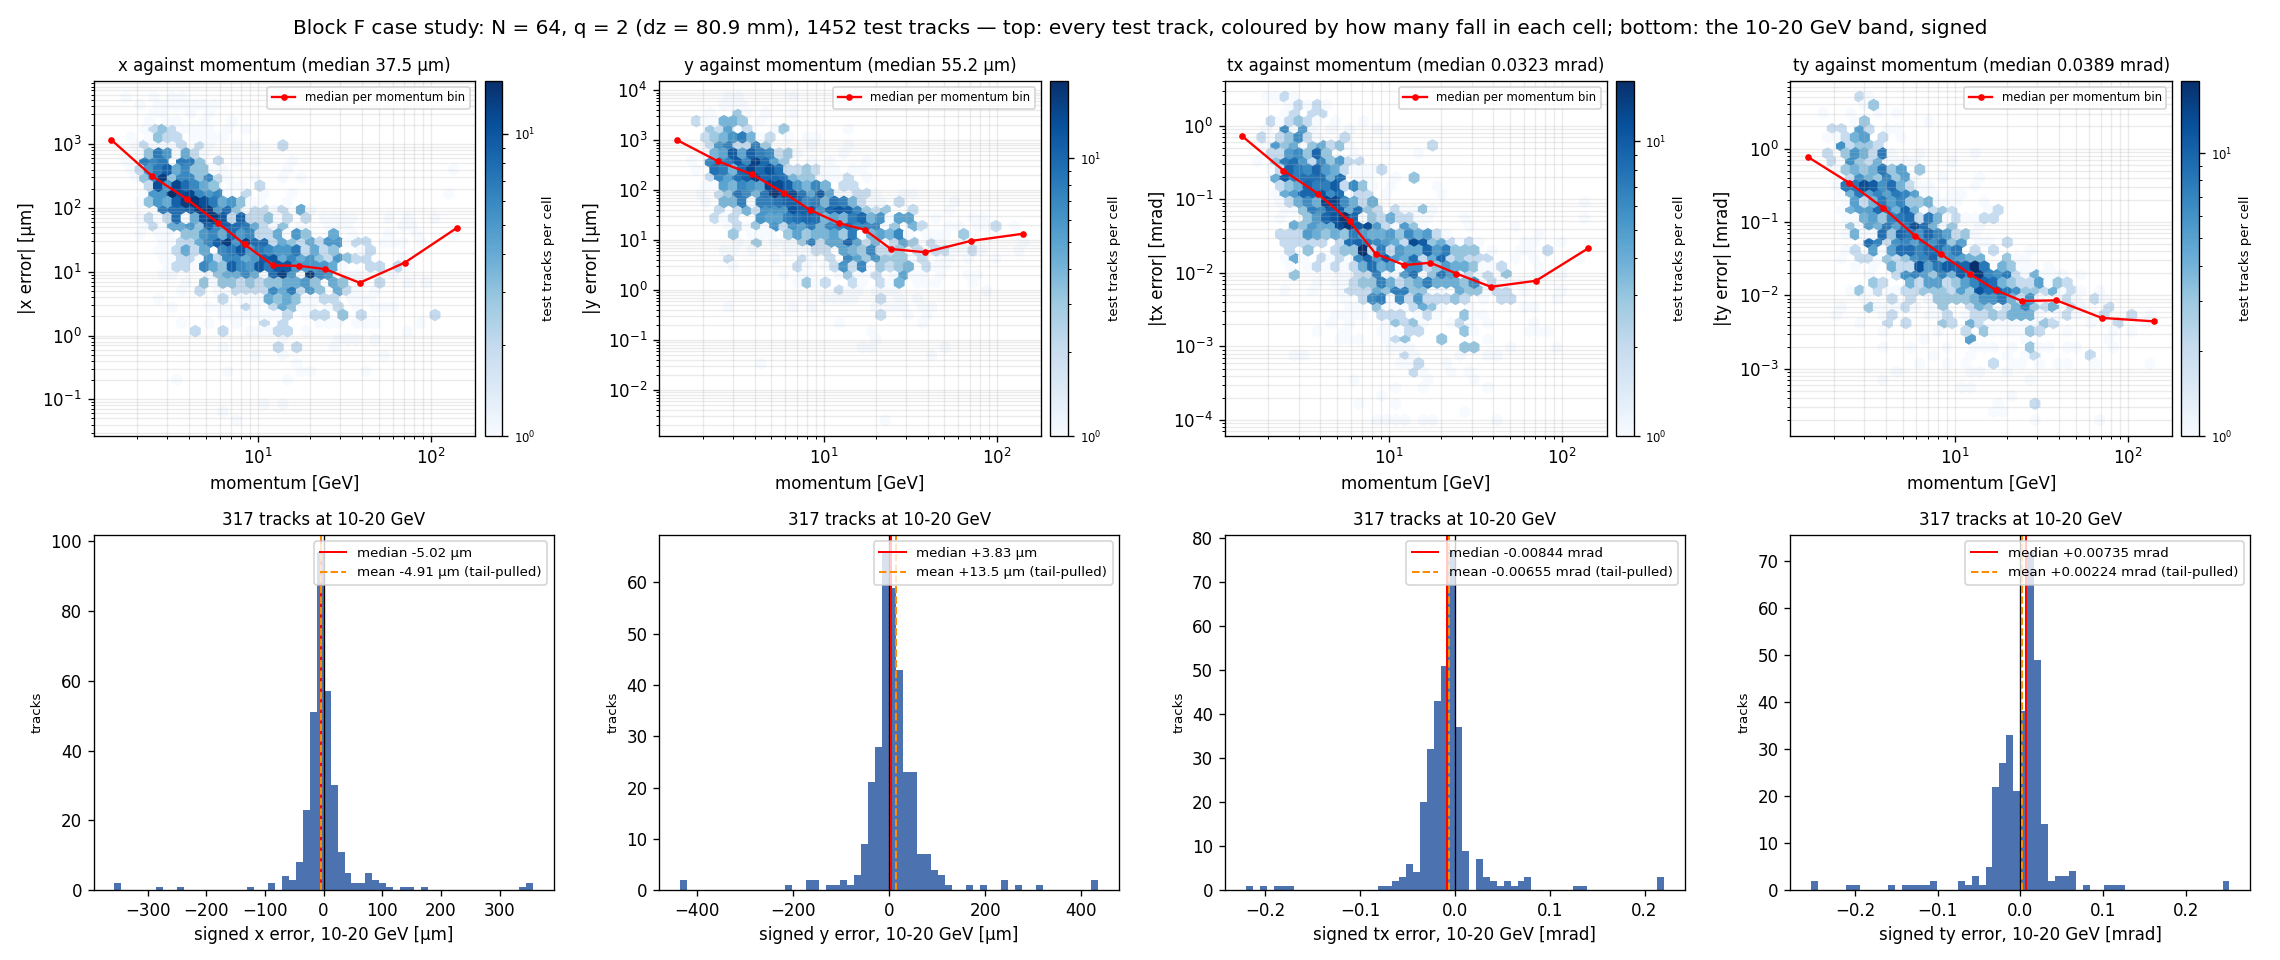

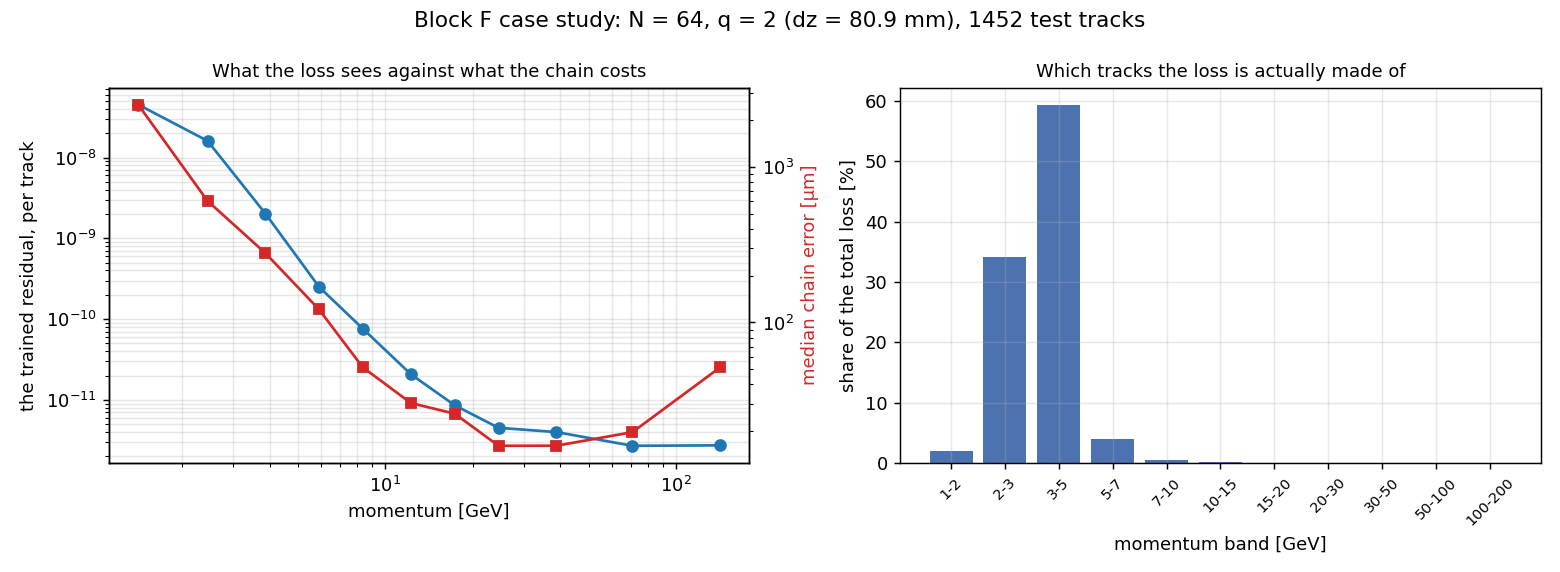

In [8]:
display(R("case_study_headline.csv")); display(R("case_study_components.csv"))
display(R("case_study_tails.csv")); display(R("case_study_loss_vs_p.csv"))
F("case_study_overview.png"); F("case_study_components.png"); F("case_study_loss_vs_p.png")

## 7. The case study with the starting x as a third axis

The same eight panels as section 6, with the track's x on the last UT plane as the extra
dimension. The flat maps hold the same numbers and are the ones to read values off.

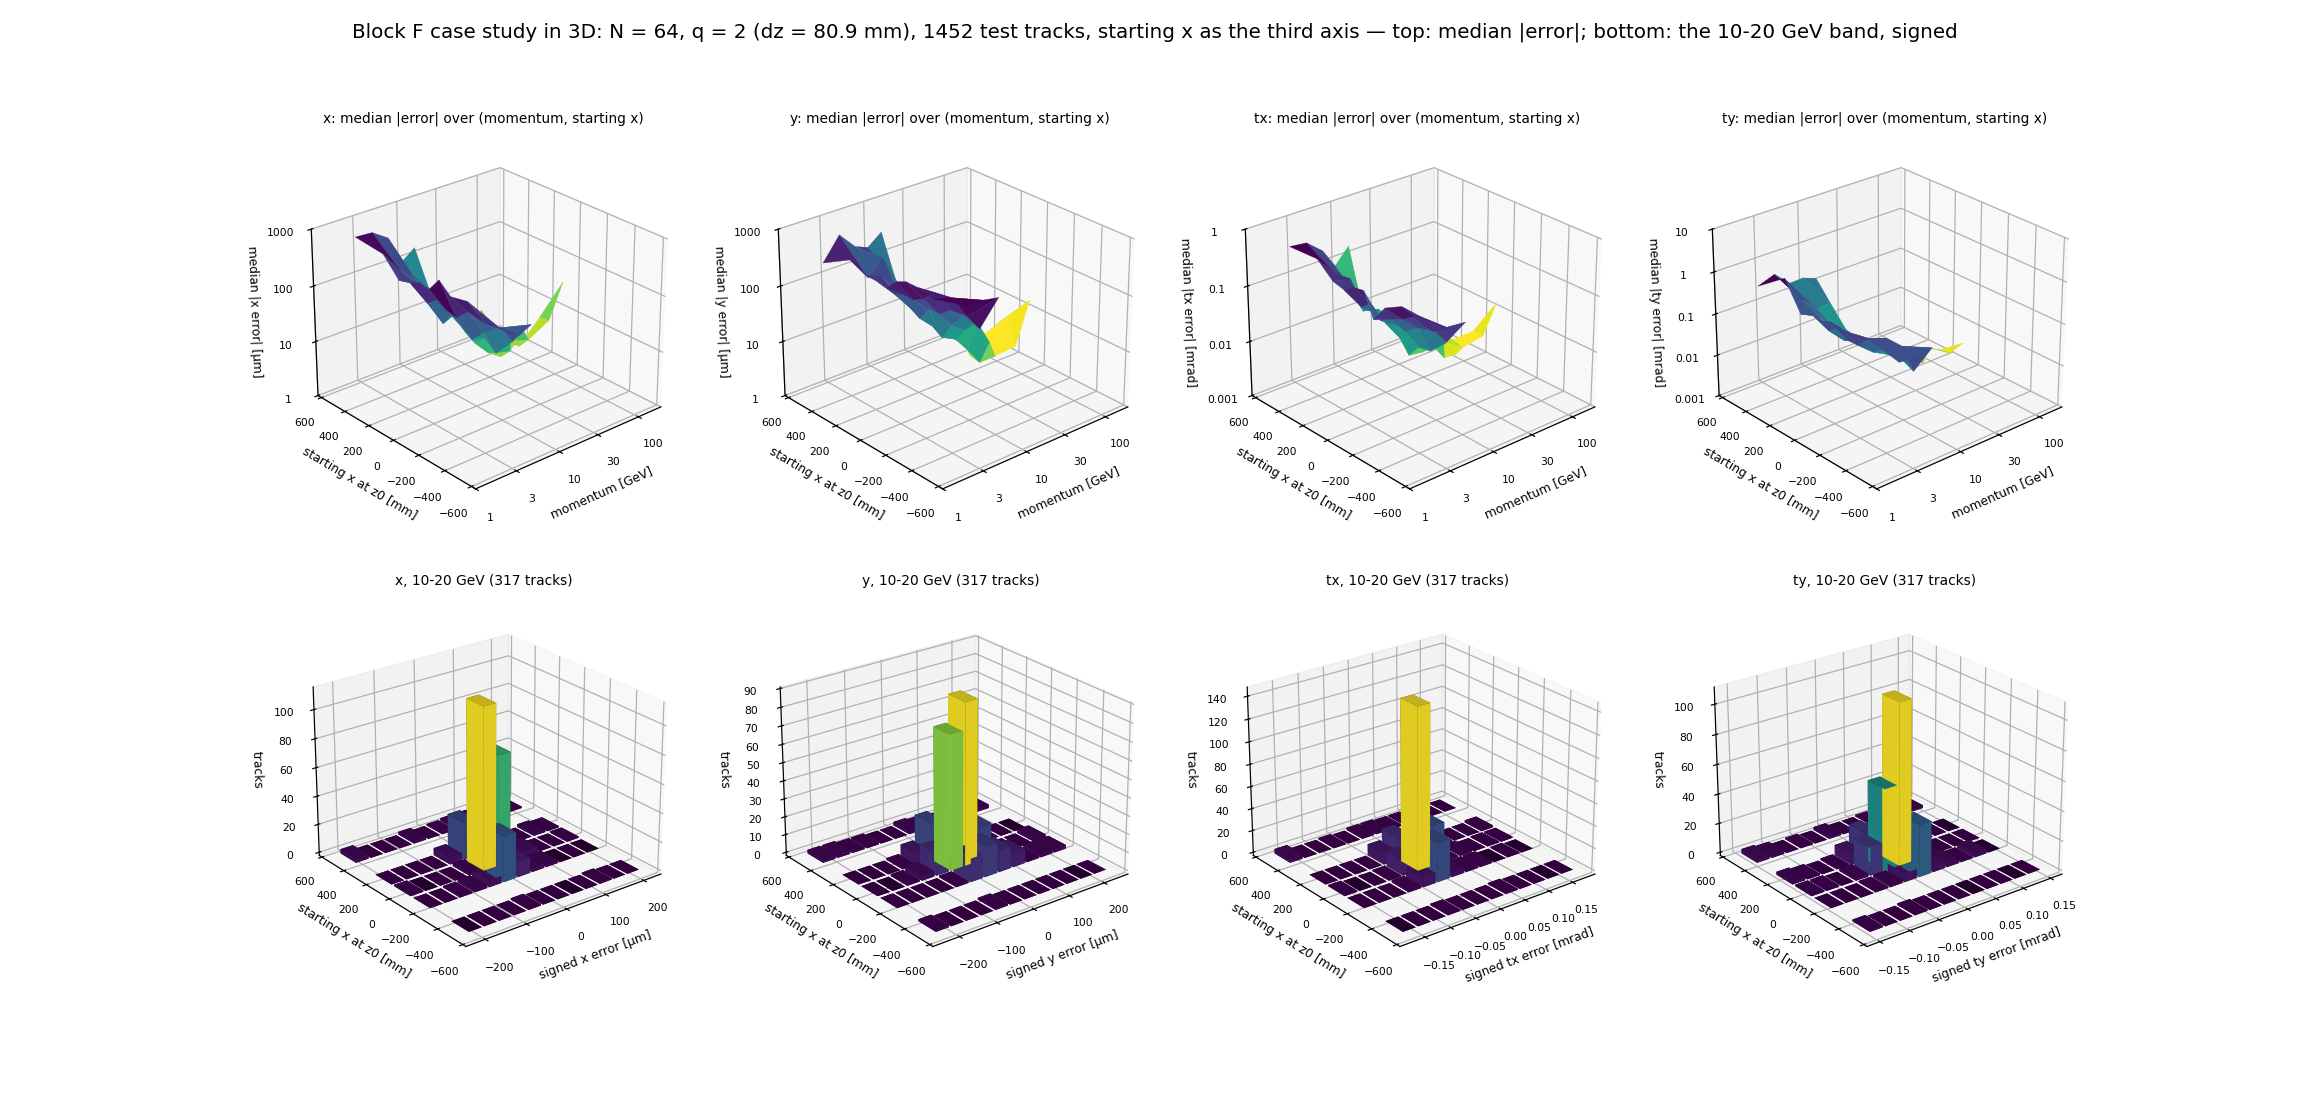

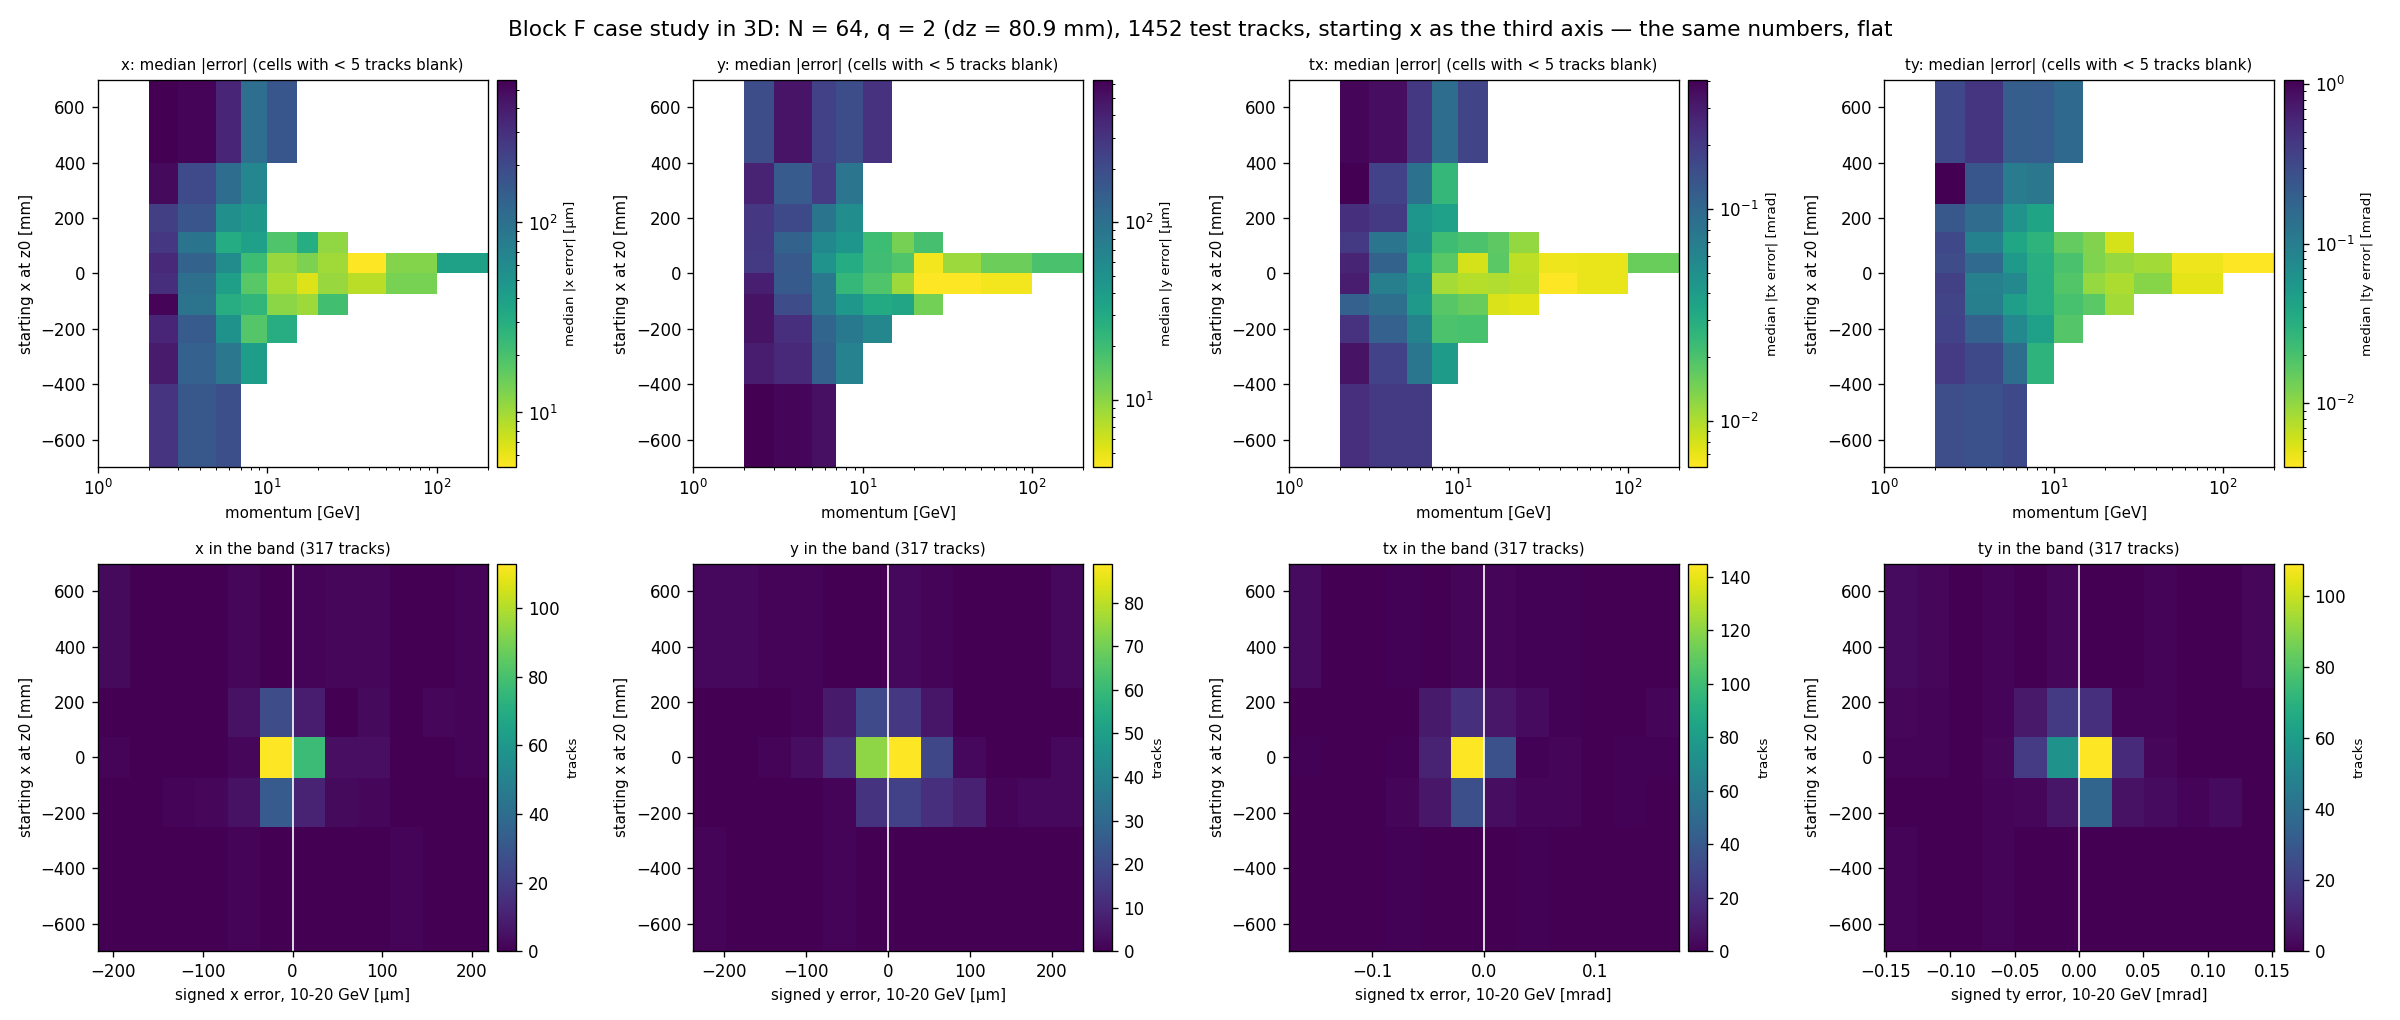

p_lo,2.0,3.0,5.0,7.0,10.0,15.0,20.0,30.0,50.0,100.0
x0_lo,,,,,,,,,,
-700.0,276.0,159.0,183.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-400.0,404.0,133.0,88.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN
-250.0,349.0,149.0,51.0,18.0,30.0,NaN,NaN,NaN,NaN,NaN
-150.0,536.0,94.0,30.0,26.0,12.0,10.0,21.0,NaN,NaN,NaN
-75.0,307.0,104.0,40.0,18.0,9.0,7.0,11.0,8.0,14.0,NaN
0.0,330.0,130.0,59.0,22.0,11.0,13.0,10.0,5.0,12.0,38.0
75.0,267.0,92.0,32.0,40.0,19.0,31.0,11.0,NaN,NaN,NaN
150.0,235.0,163.0,54.0,46.0,NaN,NaN,NaN,NaN,NaN,NaN
250.0,498.0,196.0,107.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
F("case_study_components_3d.png"); F("case_study_components_x0_maps.png")
x0 = R("case_study_error_vs_p_x0.csv")
x0[(x0["component"] == "x") & (x0["n"] >= 5)].pivot(index="x0_lo", columns="p_lo", values="med").round(0)